# MFAA Chapter 13 Laboratory
**Exposure Switchboard** (book §13.10)

The allocation cockpit: price every edge of the exposure graph, compute switching and rebalancing policies, return the policy map. Seed `20261300`.

In [1]:
import sys, numpy as np, matplotlib.pyplot as plt
sys.path.insert(0,'..')
from engine import ch13
from dataclasses import replace

## 1. L2 replication (Proposition 13.3)
Smoothing-corrected beta and the Pythagoras identity.

In [2]:
rep = ch13.replication_report(ch13.SwitchboardParams())
print(f"beta measured {rep['beta_measured']:.3f}, corrected {rep['beta_corrected']:.3f}")
print(f"total var = spanned {rep['spanned_var']:.4f} + residual {rep['residual_var']:.4f}; TE = {rep['tracking_error']:.4f}")

beta measured 0.550, corrected 1.100
total var = spanned 0.0310 + residual 0.0100; TE = 0.1000


## 2. The rebalancing-band cube-root law
Band half-width scales as ε^{1/3} over decades of proportional cost.

fitted slope 0.3333 vs target 0.3333


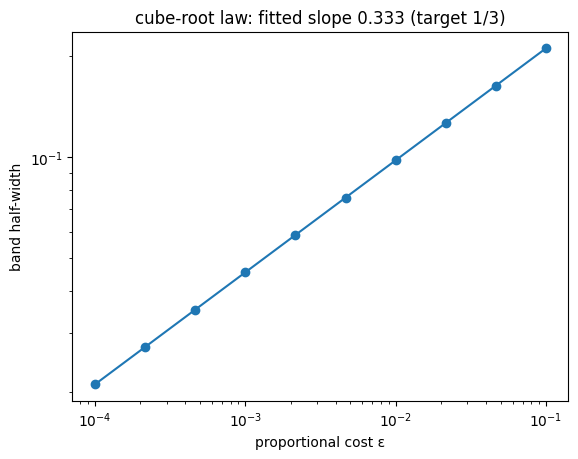

In [3]:
cr = ch13.cube_root_scaling(ch13.SwitchboardParams())
plt.loglog(cr['epsilons'], cr['half_widths'], 'o-')
plt.xlabel('proportional cost ε'); plt.ylabel('band half-width'); plt.title(f"cube-root law: fitted slope {cr['fitted_slope']:.3f} (target 1/3)")
print(f"fitted slope {cr['fitted_slope']:.4f} vs target {1/3:.4f}")

## 3. Optimal transport (Proposition 13.8)
Exact 1-D W₁ and Sinkhorn convergence as ε → 0.

In [4]:
tc = ch13.transport_convergence()
print(f"exact W1: {tc['exact_w1']:.4f}")
for r in tc['sinkhorn']: print(f"  Sinkhorn ε={r['epsilon']}: cost {r['cost']:.4f}")
print('Sinkhorn converges to the exact W1 as the regularization vanishes.')

exact W1: 0.2950
  Sinkhorn ε=1.0: cost 0.7753
  Sinkhorn ε=0.1: cost 0.3212
  Sinkhorn ε=0.01: cost 0.2953
Sinkhorn converges to the exact W1 as the regularization vanishes.


## 4. Validation checks

In [5]:
v = ch13.validation_checks()
for k,d in v.items():
    if isinstance(d,dict): print(k, 'PASS' if d['pass_'] else 'FAIL')
print('ALL:', v['all_pass'])

V1_replication PASS
V2_cube_root PASS
V3_transport PASS
V4_w1_shift PASS
V5_hysteresis PASS
V6_reproducible PASS
ALL: True
